<a href="https://colab.research.google.com/github/diyaasahare/Anemia-Analysis-/blob/main/Anemia_Analysis_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("No_Of_Women_Having_HB_Level_Less_Than_11.csv")
df.head()


,State/UT/Agency,Achievements 2009-10# Total ANC Registeration,Achievements 2009-10# Number of women having Hb level < 11 (tested cases),Achievements 2010-11# Total ANC registeration,Achievements 2010-11# Number of women having Hb level < 11 (tested cases)
0,Arunachal Pradesh,"22,414","2,480","24,151","4,858"
1,Assam,"746,492","33,883","740,545","84,265"
2,Manipur,"111,670","3,351","98,692","4,390"
3,Meghalaya,"102,540","11,286","110,804","20,675"
4,Mizoram,"32,096","1,272","29,126","2,023"


In [3]:
df.columns


Index(['State/UT/Agency', 'Achievements 2009-10# Total ANC Registeration',
       'Achievements 2009-10# Number of women having Hb level < 11 (tested cases)',
       'Achievements 2010-11# Total ANC registeration',
       'Achievements 2010-11# Number of women having Hb level < 11 (tested cases)'],
      dtype='object')

In [4]:
df.isnull().sum()


,0
State/UT/Agency,0
Achievements 2009-10# Total ANC Registeration,1
Achievements 2009-10# Number of women having Hb level < 11 (tested cases),3
Achievements 2010-11# Total ANC registeration,0
Achievements 2010-11# Number of women having Hb level < 11 (tested cases),2


In [6]:
df = df.replace(',', '', regex=True)


In [7]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric)


In [9]:
df["Anemia_%_2009_10"] = (df['Achievements 2009-10# Number of women having Hb level < 11 (tested cases)'] / df['Achievements 2009-10# Total ANC Registeration']) * 100
df["Anemia_%_2010_11"] = (df['Achievements 2010-11# Number of women having Hb level < 11 (tested cases)'] / df['Achievements 2010-11# Total ANC registeration']) * 100

df.head()

,State/UT/Agency,Achievements 2009-10# Total ANC Registeration,Achievements 2009-10# Number of women having Hb level < 11 (tested cases),Achievements 2010-11# Total ANC registeration,Achievements 2010-11# Number of women having Hb level < 11 (tested cases),Anemia_%_2009_10,Anemia_%_2010_11
0,Arunachal Pradesh,22414.0,2480.0,24151,4858.0,11.064513,20.115109
1,Assam,746492.0,33883.0,740545,84265.0,4.538964,11.378782
2,Manipur,111670.0,3351.0,98692,4390.0,3.000806,4.448182
3,Meghalaya,102540.0,11286.0,110804,20675.0,11.006437,18.659074
4,Mizoram,32096.0,1272.0,29126,2023.0,3.963111,6.945684


In [10]:
df.sort_values("Anemia_%_2010_11", ascending=False).head(5)


,State/UT/Agency,Achievements 2009-10# Total ANC Registeration,Achievements 2009-10# Number of women having Hb level < 11 (tested cases),Achievements 2010-11# Total ANC registeration,Achievements 2010-11# Number of women having Hb level < 11 (tested cases),Anemia_%_2009_10,Anemia_%_2010_11
28,A & N Islands^,5715.0,14004.0,2782,4767.0,245.03937,171.351546
33,Lakshadweep,942.0,525.0,1091,792.0,55.732484,72.593951
10,Himachal Pradesh,157805.0,67550.0,156424,99302.0,42.805995,63.482586
25,Punjab,508435.0,194590.0,511812,245949.0,38.272346,48.054559
20,Gujarat,1426797.0,593069.0,1382710,610245.0,41.56646,44.133983


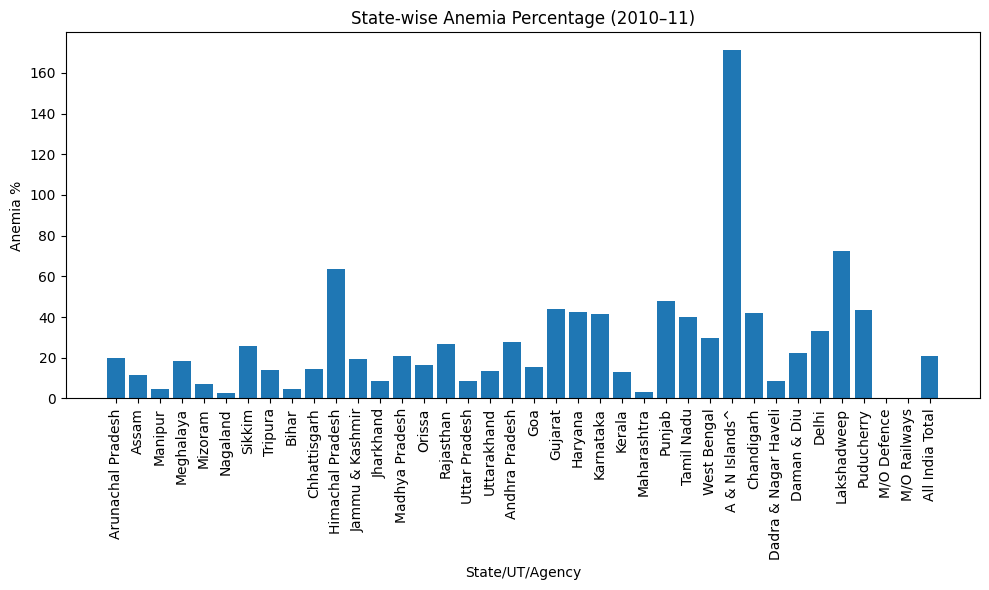

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(df["State/UT/Agency"], df["Anemia_%_2010_11"])
plt.xticks(rotation=90)
plt.title("State-wise Anemia Percentage (2010–11)")
plt.ylabel("Anemia %")
plt.xlabel("State/UT/Agency")
plt.tight_layout()
plt.show()

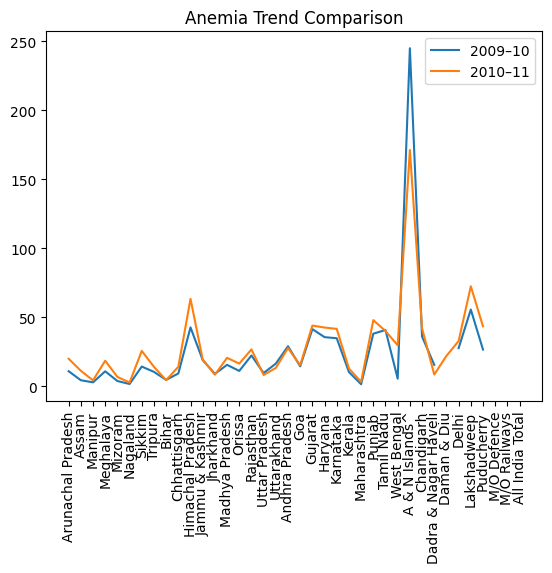

In [14]:
plt.figure()
plt.plot(df["State/UT/Agency"], df["Anemia_%_2009_10"], label="2009–10")
plt.plot(df["State/UT/Agency"], df["Anemia_%_2010_11"], label="2010–11")
plt.xticks(rotation=90)
plt.legend()
plt.title("Anemia Trend Comparison")
plt.show()